# 02 - Eksperimen Baseline & Model Gabungan
Hasil dihasilkan oleh `src/run_experiments.py` (`results/metrics.csv`). Protokol: hyperparameter dipilih dengan `TimeSeriesSplit` di train; metrik val = model train-only; metrik test = refit train+val, dipakai sekali.

In [1]:
import sys; sys.path.append('../src')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 30)
plt.rcParams.update({'figure.dpi': 90, 'axes.grid': True, 'grid.alpha': .3})
from config import ROOT
m = pd.read_csv(ROOT/'results/metrics.csv'); p = pd.read_csv(ROOT/'results/predictions_test.csv')
cols = ['model','DA','F1_macro','MCC','AUC','share_pred1']
print('VALIDASI'); print(m[m.split=='val'][cols].round(3).to_string(index=False))

VALIDASI
                     model    DA  F1_macro    MCC   AUC  share_pred1
                  majority 0.512     0.339  0.000   NaN        1.000
               persistence 0.542     0.541  0.083   NaN        0.512
                     arima 0.538     0.536  0.073   NaN        0.550
               logreg:kurs 0.512     0.339  0.000 0.559        1.000
                  xgb:kurs 0.546     0.505  0.093 0.555        0.775
        logreg:kurs+volcat 0.529     0.515  0.053 0.539        0.658
           xgb:kurs+volcat 0.517     0.511  0.029 0.548        0.596
     logreg:kurs+lex_title 0.512     0.339  0.000 0.582        1.000
        xgb:kurs+lex_title 0.571     0.522  0.160 0.604        0.808
  logreg:kurs+lex_title_kp 0.512     0.339  0.000 0.566        1.000
     xgb:kurs+lex_title_kp 0.500     0.438 -0.021 0.530        0.821
   logreg:kurs+tfidf_title 0.512     0.471  0.014 0.556        0.767
      xgb:kurs+tfidf_title 0.517     0.472  0.023 0.535        0.779
logreg:kurs+tfidf_title_k

In [2]:
t = m[m.split=='test'][cols+['DA_lo','DA_hi','p_vs_majority']].round(3)
print('TEST'); print(t.to_string(index=False))

TEST
                     model    DA  F1_macro    MCC   AUC  share_pred1  DA_lo  DA_hi  p_vs_majority
                  majority 0.573     0.364  0.000   NaN        1.000  0.510  0.631          0.527
               persistence 0.531     0.520  0.041   NaN        0.577  0.469  0.593          0.914
                     arima 0.519     0.500  0.002   NaN        0.622  0.452  0.585          0.960
               logreg:kurs 0.573     0.364  0.000 0.532        1.000  0.510  0.631          0.527
                  xgb:kurs 0.552     0.517  0.051 0.521        0.697  0.490  0.618          0.763
        logreg:kurs+volcat 0.539     0.489  0.010 0.509        0.743  0.477  0.598          0.866
           xgb:kurs+volcat 0.544     0.505  0.030 0.527        0.705  0.481  0.606          0.836
     logreg:kurs+lex_title 0.573     0.397  0.027 0.517        0.967  0.510  0.635          0.527
        xgb:kurs+lex_title 0.531     0.496  0.007 0.533        0.693  0.469  0.593          0.914
  logreg:kurs+l

`share_pred1` = proporsi prediksi 'IDR melemah'. Nilai ~1 berarti model degenerate (hampir selalu menebak mayoritas); DA-nya sama dengan majority dan **tidak** menunjukkan kemampuan prediksi (lihat F1 macro & MCC).

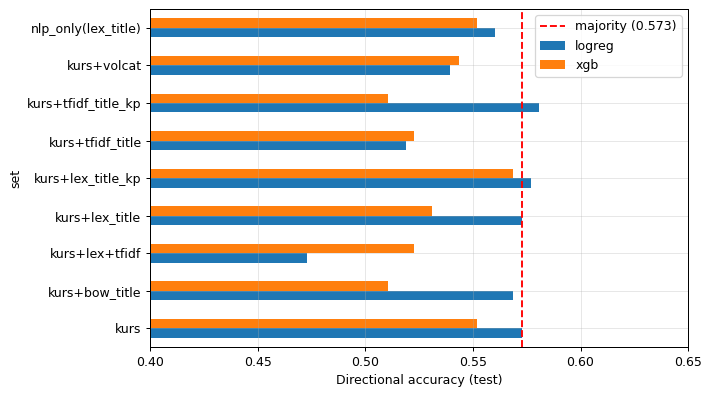

In [3]:
# Ablation: DA test tiap set fitur, dua learner
t = m[m.split=='test'].copy()
t['learner'] = t.model.str.split(':').str[0]; t['set'] = t.model.str.split(':').str[1]
ab = t[t.learner.isin(['logreg','xgb'])].pivot(index='set', columns='learner', values='DA')
maj = m[(m.model=='majority')&(m.split=='test')].DA.iloc[0]
ax = ab.plot.barh(figsize=(8,4.5)); ax.axvline(maj, color='r', ls='--', label=f'majority ({maj:.3f})')
ax.set_xlim(.4,.65); ax.set_xlabel('Directional accuracy (test)'); ax.legend(); plt.tight_layout(); plt.show()

In [4]:
from evaluate import cm_table
for name in ['majority','xgb:kurs','xgb:kurs+lex_title','logreg:kurs+tfidf_title_kp']:
    print(name); print(cm_table(p['y'], p[name]).to_string(), '\n')

majority
                       pred_0  pred_1
aktual_0(tdk melemah)       0     103
aktual_1(melemah)           0     138 

xgb:kurs
                       pred_0  pred_1
aktual_0(tdk melemah)      34      69
aktual_1(melemah)          39      99 

xgb:kurs+lex_title
                       pred_0  pred_1
aktual_0(tdk melemah)      32      71
aktual_1(melemah)          42      96 

logreg:kurs+tfidf_title_kp
                       pred_0  pred_1
aktual_0(tdk melemah)       2     101
aktual_1(melemah)           0     138 



In [5]:
mc = pd.read_csv(ROOT/'results/mcnemar_vs_kurs_only.csv'); print(mc.round(3).to_string(index=False))

                     model          vs  p_mcnemar
        logreg:kurs+volcat logreg:kurs      0.374
     logreg:kurs+lex_title logreg:kurs      1.000
  logreg:kurs+lex_title_kp logreg:kurs      1.000
   logreg:kurs+tfidf_title logreg:kurs      0.154
logreg:kurs+tfidf_title_kp logreg:kurs      0.500
     logreg:kurs+bow_title logreg:kurs      1.000
     logreg:kurs+lex+tfidf logreg:kurs      0.020
logreg:nlp_only(lex_title) logreg:kurs      0.375
           xgb:kurs+volcat    xgb:kurs      0.885
        xgb:kurs+lex_title    xgb:kurs      0.649
     xgb:kurs+lex_title_kp    xgb:kurs      0.704
      xgb:kurs+tfidf_title    xgb:kurs      0.450
   xgb:kurs+tfidf_title_kp    xgb:kurs      0.237
        xgb:kurs+bow_title    xgb:kurs      0.302
        xgb:kurs+lex+tfidf    xgb:kurs      0.530
   xgb:nlp_only(lex_title)    xgb:kurs      1.000


## Ringkasan temuan
- Di test (241 hari, majority = 57,3%), **tidak ada** model yang berbeda signifikan dari majority (semua `p_vs_majority` ≥ 0,42; CI 95% bootstrap lebar, sekitar ±6 poin).
- Penambahan fitur NLP (lexicon, TF-IDF, BoW) **tidak** meningkatkan model kurs-saja secara signifikan (uji McNemar); AUC sekitar 0,5. Satu kombinasi (logreg kurs+lex+tfidf, DA 0,473) justru signifikan lebih buruk (p = 0,02), indikasi overfitting pada dimensi tinggi.
- Model kurs+NLP terkuat secara numerik (mis. logreg+tfidf_title_kp, DA 0,581) hampir semata-mata menebak kelas mayoritas (`share_pred1` ~0,99).
- Interpretasi: sinyal harian judul/keypoints CNBC lemah relatif terhadap noise; ukuran sampel kecil membatasi kemampuan mendeteksi efek kecil. Ini menjadi baseline jujur untuk Tugas 3 (mis. agregasi berbasis topik/kejadian, horizon lebih panjang, target volatilitas).